
# Hybrid Iterative MF destriping

この notebook は、以下の2段階で `alpha_map` の stripe / line artifact を補正します。

1. **太い線・センサ由来ノイズ除去**  
   添付 notebook `run_roi_mf_fixed_full_image_slopes.ipynb` の broad cleanup の考え方を使い、固定 slope 群に沿って **median のみ** で太い帯状成分を推定して引きます。

2. **細い高 alpha 線除去**  
   `improved_iterative_mf_two_direction_destriping_stat_compare.ipynb` と同様に、細い線に対して `median`, `mean`, `trimmed_mean`, `sigma_clipped_mean`, `mode` など複数の統計量を試します。

基本は **Iterative MF を通常通り実行 → 最終 alpha に broad median → thin statistical cleanup** です。  
必要なら `RUN_EACH_ITER_HYBRID=True` にすると、各 iteration の plume 判定前に broad+thin を入れる比較もできます。


In [1]:

# ============================================================
# 0. Imports and user settings
# ============================================================
from __future__ import annotations

import re
from pathlib import Path
from typing import Optional, Sequence, Union

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# Input files
# ----------------------------
ROI_CSV = Path(r"D:/research/code/all_roi_spectra200x200.csv")
MODTRAN_CSV = Path(r"E:/refit/CH4c.csv")
METADATA_TXT = Path(r"HSHL1G_N320W1032_20221030160051_20231127193053.txt")

OUTPUT_DIR = Path(r"D:/research/code/outputs_hybrid_broad_median_thin_stats")

# ----------------------------
# Wavelength / UAS settings
# ----------------------------
WL_MIN = 2100.0
WL_MAX = 2450.0
FWHM_NM = 12.5
UAS_ALPHA_MIN = 0.0
UAS_ALPHA_MAX = 0.5

# ----------------------------
# Iterative MF settings
# ----------------------------
N_ITER = 5
NSIGMA = 3.0
REG = 1e-6
RCOND = 1e-8

# ----------------------------
# Valid pixel settings
# ----------------------------
NODATA_VALUES = [0, -9999]
REQUIRE_POSITIVE = True
MIN_VALID_FRACTION = 1.0

# ============================================================
# Broad sensor-noise cleanup settings
# ============================================================
# 添付 run_roi_mf_fixed_full_image_slopes.ipynb の broad cleanup に相当。
# 太い線の除去には median のみを使う。
# slope は y = slope*x + b、つまり row - slope*col = const の線群として扱う。
BROAD_SLOPES = [0.9775, 1.2664, 2.5575]
# 必要なら 1.2520 も追加:
# BROAD_SLOPES = [0.9775, 1.2520, 1.2664, 2.5575]

BROAD_METHOD = "median"
BROAD_LINE_BIN_WIDTH = 18.0
BROAD_MIN_PIXELS_PER_LINE = 80
BROAD_EXCLUDE_MODE = "robust_high"  # "none", "robust_high", "previous_plume", "previous_plume_or_high"
BROAD_SMOOTH_HALF_WINDOW = 0

# ============================================================
# Thin high-alpha-line cleanup settings
# ============================================================
# improved_iterative_mf_two_direction_destriping_stat_compare.ipynb 側の思想。
# 細い線には複数統計量を試す。
THIN_SLOPES = [1.0, -1.0]  # y=x と y=-x。必要なら [0.9775, -1.2664] などに変更。
THIN_LINE_BIN_WIDTH = 2.0
THIN_MIN_PIXELS_PER_LINE = 15
THIN_EXCLUDE_MODE = "none"  # 細い高alpha線自体を推定したいのでまず none 推奨
THIN_SMOOTH_HALF_WINDOW = 0

THIN_STAT_METHODS = [
    "median",
    "mean",
    "trimmed_mean",
    "sigma_clipped_mean",
    "mode",
    "quantile_75",
    "quantile_90",
    "upper_mean_75",
]

# ----------------------------
# Statistic parameters
# ----------------------------
TRIM_FRACTION = 0.1
MODE_BINS = 64
SIGMA_CLIP_NSIGMA = 3.0
SIGMA_CLIP_MAX_ITER = 3

# ----------------------------
# Experiment switches
# ----------------------------
RUN_FINAL_ONLY_HYBRID = True
RUN_BROAD_ONLY_REFERENCE = True
RUN_EACH_ITER_HYBRID = True  # 重いのでデフォルト False。必要なら True。

# final-only の場合、広い帯状ノイズを引いた後に細い線を引く。
# each-iter の場合、各 iteration で同じ順序の補正を入れて plume 判定する。


In [2]:

# ============================================================
# 1. Data loading helpers
# ============================================================

def get_wave_columns(df: pd.DataFrame) -> tuple[list[str], np.ndarray]:
    wave_cols: list[str] = []
    wavelengths: list[float] = []
    pattern = re.compile(r"^wave_([0-9]+(?:\.[0-9]+)?)nm$")
    for col in df.columns:
        m = pattern.match(col)
        if m is not None:
            wave_cols.append(col)
            wavelengths.append(float(m.group(1)))
    if len(wave_cols) == 0:
        raise ValueError("No wavelength columns like wave_2300nm were found.")
    wavelengths = np.asarray(wavelengths, dtype=float)
    order = np.argsort(wavelengths)
    return [wave_cols[i] for i in order], wavelengths[order]


def load_roi_spectra_csv(path: str | Path) -> tuple[pd.DataFrame, np.ndarray, np.ndarray]:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"ROI CSV not found: {path}")
    df = pd.read_csv(path)
    if "y" not in df.columns or "x" not in df.columns:
        raise ValueError("ROI CSV must contain y and x columns.")
    wave_cols, wavelengths = get_wave_columns(df)
    spectra = df[wave_cols].to_numpy(dtype=float)
    return df, wavelengths, spectra


def spectra_to_cube(df: pd.DataFrame, spectra: np.ndarray, fill_value=np.nan):
    ys = np.sort(df["y"].unique())
    xs = np.sort(df["x"].unique())
    y_to_i = {y: i for i, y in enumerate(ys)}
    x_to_j = {x: j for j, x in enumerate(xs)}
    H, W = len(ys), len(xs)
    B = spectra.shape[1]
    cube = np.full((H, W, B), fill_value, dtype=float)
    for row_idx, row in df.iterrows():
        cube[y_to_i[row["y"]], x_to_j[row["x"]], :] = spectra[row_idx, :]
    return cube, ys, xs


def band_mask(wavelengths, wl_min=None, wl_max=None, exclude_ranges=None):
    mask = np.ones_like(wavelengths, dtype=bool)
    if wl_min is not None:
        mask &= wavelengths >= wl_min
    if wl_max is not None:
        mask &= wavelengths <= wl_max
    if exclude_ranges is not None:
        for a, b in exclude_ranges:
            mask &= ~((wavelengths >= a) & (wavelengths <= b))
    return mask


def select_bands(cube, wavelengths, wl_min, wl_max, exclude_ranges=None):
    mask = band_mask(wavelengths, wl_min, wl_max, exclude_ranges)
    return cube[:, :, mask], wavelengths[mask], mask


In [3]:

# ============================================================
# 2. Plotting helpers
# ============================================================

def finite_values(img: np.ndarray, mask: Optional[np.ndarray] = None) -> np.ndarray:
    arr = np.asarray(img, dtype=float)
    if mask is None:
        vals = arr[np.isfinite(arr)]
    else:
        vals = arr[np.isfinite(arr) & np.asarray(mask, dtype=bool)]
    return vals


def robust_limits(images, mask=None, q_low=2.0, q_high=98.0):
    if isinstance(images, np.ndarray):
        images = [images]
    vals_list = []
    for img in images:
        vals = finite_values(img, mask=mask)
        if vals.size:
            vals_list.append(vals)
    if not vals_list:
        return -1.0, 1.0
    vals = np.concatenate(vals_list)
    lo, hi = np.nanpercentile(vals, [q_low, q_high])
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        med = float(np.nanmedian(vals))
        std = float(np.nanstd(vals)) or 1.0
        lo, hi = med - std, med + std
    return float(lo), float(hi)


def plot_map(img, title="map", mask=None, vmin=None, vmax=None, cmap="viridis"):
    if vmin is None or vmax is None:
        vmin0, vmax0 = robust_limits(img, mask=mask)
        vmin = vmin0 if vmin is None else vmin
        vmax = vmax0 if vmax is None else vmax
    plt.figure(figsize=(5, 5))
    im = plt.imshow(img, origin="upper", vmin=vmin, vmax=vmax, cmap=cmap)
    plt.colorbar(im, fraction=0.046)
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.show()


def plot_case_overview(name: str, res: dict, output_dir: Optional[Path] = None, common_limits=None):
    valid = res["valid_mask"]
    raw = res["alpha_final_raw"]
    corr = res["alpha_final_corrected"]
    stripe = res["stripe_map_final"]
    plume = res["plume_mask_final"]
    if common_limits is None:
        vmin, vmax = robust_limits([raw, corr], mask=valid)
    else:
        vmin, vmax = common_limits
    svmin, svmax = robust_limits(stripe, mask=valid)

    fig, axes = plt.subplots(1, 4, figsize=(17, 4.2), constrained_layout=True)
    im0 = axes[0].imshow(raw, origin="upper", vmin=vmin, vmax=vmax)
    axes[0].set_title("raw alpha")
    plt.colorbar(im0, ax=axes[0], fraction=0.046)
    im1 = axes[1].imshow(stripe, origin="upper", vmin=svmin, vmax=svmax)
    axes[1].set_title("estimated stripe")
    plt.colorbar(im1, ax=axes[1], fraction=0.046)
    im2 = axes[2].imshow(corr, origin="upper", vmin=vmin, vmax=vmax)
    axes[2].set_title("corrected alpha")
    plt.colorbar(im2, ax=axes[2], fraction=0.046)
    im3 = axes[3].imshow(plume, origin="upper")
    axes[3].set_title("plume mask")
    plt.colorbar(im3, ax=axes[3], fraction=0.046)
    fig.suptitle(name)
    if output_dir is not None:
        output_dir.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_dir / f"{name}_overview.png", dpi=180)
    plt.show()


In [4]:

# ============================================================
# 3. MODTRAN / UAS helpers
# ============================================================

def load_ch4_modtran_csv(path: str | Path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"MODTRAN CSV not found: {path}")
    df = pd.read_csv(path)
    if "wavelength" not in df.columns:
        raise ValueError("MODTRAN CSV must contain wavelength column.")
    mod_wave = df["wavelength"].to_numpy(dtype=float)
    alpha_cols = [c for c in df.columns if c != "wavelength"]
    alpha_grid = np.array([float(c) for c in alpha_cols], dtype=float)
    order = np.argsort(alpha_grid)
    alpha_grid = alpha_grid[order]
    alpha_cols = [alpha_cols[i] for i in order]
    spectra_grid = df[alpha_cols].to_numpy(dtype=float).T
    return mod_wave, alpha_grid, spectra_grid


def gaussian_srf_resample(mod_wave, mod_spectra, sensor_wave, fwhm_nm):
    mod_wave = np.asarray(mod_wave, dtype=float)
    mod_spectra = np.asarray(mod_spectra, dtype=float)
    sensor_wave = np.asarray(sensor_wave, dtype=float)
    if np.isscalar(fwhm_nm):
        fwhm_arr = np.full(sensor_wave.shape, float(fwhm_nm))
    else:
        fwhm_arr = np.asarray(fwhm_nm, dtype=float)
    out = np.zeros((mod_spectra.shape[0], sensor_wave.size), dtype=float)
    for j, center in enumerate(sensor_wave):
        sigma = fwhm_arr[j] / (2.0 * np.sqrt(2.0 * np.log(2.0)))
        use = np.abs(mod_wave - center) <= 4.0 * sigma
        if np.sum(use) < 2:
            for i in range(mod_spectra.shape[0]):
                out[i, j] = np.interp(center, mod_wave, mod_spectra[i])
        else:
            w = np.exp(-0.5 * ((mod_wave[use] - center) / sigma) ** 2)
            w /= np.sum(w)
            out[:, j] = mod_spectra[:, use] @ w
    return out


def compute_uas_log_slope(alpha_grid, spectra_grid, alpha_min=None, alpha_max=None):
    alpha_grid = np.asarray(alpha_grid, dtype=float)
    spectra_grid = np.asarray(spectra_grid, dtype=float)
    use = np.ones_like(alpha_grid, dtype=bool)
    if alpha_min is not None:
        use &= alpha_grid >= alpha_min
    if alpha_max is not None:
        use &= alpha_grid <= alpha_max
    a = alpha_grid[use]
    Y = np.log(np.maximum(spectra_grid[use], 1e-30))
    if a.size < 2:
        raise ValueError("Not enough alpha points for UAS fit.")
    A = np.vstack([np.ones_like(a), a]).T
    coeff, *_ = np.linalg.lstsq(A, Y, rcond=None)
    intercept = coeff[0]
    slope = coeff[1]
    uas = -slope
    return uas, intercept


In [5]:

# ============================================================
# 4. Matched Filter helpers
# ============================================================

def make_valid_pixel_mask(cube, nodata_values=None, require_positive=True, min_valid_fraction=1.0):
    valid_band = np.isfinite(cube)
    if nodata_values is not None:
        for value in nodata_values:
            valid_band &= cube != value
    if require_positive:
        valid_band &= cube > 0
    return np.mean(valid_band, axis=2) >= min_valid_fraction


def estimate_background_mean_cov_from_cube(cube, background_mask, reg=1e-6, min_pixels=None):
    H, W, B = cube.shape
    if min_pixels is None:
        min_pixels = max(B + 5, 30)
    X = cube[np.asarray(background_mask, dtype=bool)]
    X = X[np.all(np.isfinite(X), axis=1)]
    if X.shape[0] < min_pixels:
        raise ValueError(f"Too few background pixels: {X.shape[0]} < {min_pixels}")
    mu = np.mean(X, axis=0)
    Xc = X - mu
    cov = (Xc.T @ Xc) / max(X.shape[0] - 1, 1)
    cov = cov + reg * np.eye(B)
    return mu, cov, X


def make_methane_target(mu, uas, positive_alpha=True):
    mu = np.asarray(mu, dtype=float)
    uas = np.asarray(uas, dtype=float)
    return -mu * uas if positive_alpha else mu * uas


def matched_filter_map_from_cube(cube, uas, valid_mask, background_mask, reg=1e-6, rcond=1e-8):
    H, W, B = cube.shape
    mu, cov, _ = estimate_background_mean_cov_from_cube(cube, background_mask, reg=reg)
    target = make_methane_target(mu, uas, positive_alpha=True)
    inv_cov = np.linalg.pinv(cov, rcond=rcond)
    denom = float(target.T @ inv_cov @ target)
    if abs(denom) < 1e-15:
        raise ValueError("MF denominator is too small.")
    alpha = np.full((H, W), np.nan, dtype=float)
    X = cube[valid_mask]
    diff = X - mu
    alpha_values = (diff @ inv_cov @ target) / denom
    alpha[valid_mask] = alpha_values
    return alpha, mu, cov, target


def robust_threshold_from_values(values, nsigma=3.0):
    v = np.asarray(values, dtype=float)
    v = v[np.isfinite(v)]
    if v.size == 0:
        return np.nan, np.nan, np.nan
    med = float(np.nanmedian(v))
    mad = float(np.nanmedian(np.abs(v - med)))
    rstd = 1.4826 * mad + 1e-12
    thr = med + nsigma * rstd
    return float(thr), med, float(rstd)


def plume_mask_from_alpha(alpha, valid_mask, nsigma=3.0):
    thr, med, rstd = robust_threshold_from_values(alpha[valid_mask], nsigma=nsigma)
    plume = np.zeros_like(alpha, dtype=bool)
    plume[valid_mask] = alpha[valid_mask] > thr
    meta = {"threshold": thr, "median": med, "robust_std": rstd, "plume_pixels": int(np.sum(plume))}
    return plume, meta


def run_baseline_iterative_mf(cube, uas, valid_mask, n_iter=5, nsigma=3.0, reg=1e-6, rcond=1e-8, verbose=True):
    background_mask = valid_mask.copy()
    alpha_history = []
    plume_history = []
    background_history = []
    threshold_meta_history = []
    mu_history = []
    cov_history = []
    prev_plume = None
    converged_iter = None

    for it in range(1, n_iter + 1):
        alpha, mu, cov, target = matched_filter_map_from_cube(
            cube, uas, valid_mask=valid_mask, background_mask=background_mask, reg=reg, rcond=rcond
        )
        plume, meta = plume_mask_from_alpha(alpha, valid_mask, nsigma=nsigma)
        new_background = valid_mask & (~plume)

        alpha_history.append(alpha.copy())
        plume_history.append(plume.copy())
        background_history.append(background_mask.copy())
        threshold_meta_history.append(meta.copy())
        mu_history.append(mu.copy())
        cov_history.append(cov.copy())

        if verbose:
            print(
                f"iter {it:02d} | bg={int(np.sum(background_mask)):7d} | "
                f"thr={meta['threshold']:+.6e} | rstd={meta['robust_std']:.6e} | "
                f"plume={int(np.sum(plume)):7d}"
            )
        if prev_plume is not None and np.array_equal(prev_plume, plume):
            converged_iter = it
            background_mask = new_background
            if verbose:
                print(f"Converged at iteration {it}.")
            break
        prev_plume = plume.copy()
        background_mask = new_background

    return {
        "alpha_raw_history": alpha_history,
        "alpha_used_history": alpha_history,
        "alpha_corr_history": alpha_history,
        "plume_history": plume_history,
        "background_history": background_history,
        "threshold_meta_history": threshold_meta_history,
        "mu_history": mu_history,
        "cov_history": cov_history,
        "alpha_final_raw": alpha_history[-1],
        "alpha_final_corrected": alpha_history[-1],
        "alpha_final_used": alpha_history[-1],
        "stripe_map_final": np.zeros_like(alpha_history[-1], dtype=float),
        "directional_stripe_maps_final": {},
        "plume_mask_final": plume_history[-1],
        "background_mask_final": background_mask,
        "threshold_meta_final": threshold_meta_history[-1],
        "line_table_final": pd.DataFrame(),
        "valid_mask": valid_mask,
        "converged_iter": converged_iter,
        "destripe_when": "none",
        "destripe_params": None,
    }


In [6]:

# ============================================================
# 5. Hybrid line-destriping helpers
# ============================================================

def statistic_1d(values: np.ndarray, method: str = "median") -> float:
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return np.nan

    if method == "median":
        return float(np.nanmedian(values))
    if method == "mean":
        return float(np.nanmean(values))
    if method == "trimmed_mean":
        v = np.sort(values)
        k = int(np.floor(TRIM_FRACTION * v.size))
        if 2 * k >= v.size:
            return float(np.nanmean(v))
        return float(np.nanmean(v[k:v.size - k]))
    if method == "sigma_clipped_mean":
        clipped = values.copy()
        for _ in range(int(SIGMA_CLIP_MAX_ITER)):
            if clipped.size < 3:
                break
            med = float(np.nanmedian(clipped))
            mad = float(np.nanmedian(np.abs(clipped - med)))
            robust_std = 1.4826 * mad
            if not np.isfinite(robust_std) or robust_std <= 0:
                std = float(np.nanstd(clipped))
                if not np.isfinite(std) or std <= 0:
                    break
                keep = np.abs(clipped - med) <= SIGMA_CLIP_NSIGMA * std
            else:
                keep = np.abs(clipped - med) <= SIGMA_CLIP_NSIGMA * robust_std
            if np.all(keep) or not np.any(keep):
                break
            clipped = clipped[keep]
        return float(np.nanmean(clipped))
    if method == "mode":
        if values.size == 1 or np.allclose(values, values[0]):
            return float(values[0])
        # 極端な外れ値で histogram 範囲が広がりすぎないように robust range を使う。
        lo, hi = np.nanpercentile(values, [1, 99])
        v = values[(values >= lo) & (values <= hi)]
        if v.size < 3:
            v = values
        counts, edges = np.histogram(v, bins=MODE_BINS)
        idx = int(np.argmax(counts))
        return float(0.5 * (edges[idx] + edges[idx + 1]))
    if method.startswith("quantile_"):
        q = float(method.split("_", 1)[1])
        return float(np.nanpercentile(values, q))
    if method.startswith("upper_mean_"):
        q = float(method.split("_", 2)[2])
        cutoff = float(np.nanpercentile(values, q))
        upper = values[values >= cutoff]
        if upper.size == 0:
            return float(np.nanmean(values))
        return float(np.nanmean(upper))
    raise ValueError(f"Unknown statistic method: {method}")


def line_id_map_for_slope(shape: tuple[int, int], slope: float, line_bin_width: float) -> np.ndarray:
    rows, cols = np.indices(shape)
    # line: row - slope * col = const
    # line_bin_width を大きくすると太い帯としてまとめる。
    return np.rint((rows - float(slope) * cols) / float(line_bin_width)).astype(np.int32)


def make_exclude_mask(alpha, valid_mask, plume_mask=None, exclude_mode="none", nsigma=3.0):
    finite = np.isfinite(alpha)
    valid = valid_mask & finite
    exclude = np.zeros_like(valid, dtype=bool)

    if exclude_mode in [None, "none"]:
        return exclude

    high = np.zeros_like(valid, dtype=bool)
    if exclude_mode in ["robust_high", "previous_plume_or_high"]:
        thr, med, rstd = robust_threshold_from_values(alpha[valid], nsigma=nsigma)
        high[valid] = alpha[valid] > thr

    plume = np.zeros_like(valid, dtype=bool)
    if plume_mask is not None and exclude_mode in ["previous_plume", "previous_plume_or_high"]:
        plume = np.asarray(plume_mask, dtype=bool) & valid

    if exclude_mode == "robust_high":
        exclude = high
    elif exclude_mode == "previous_plume":
        exclude = plume
    elif exclude_mode == "previous_plume_or_high":
        exclude = plume | high
    else:
        raise ValueError(f"Unknown exclude_mode: {exclude_mode}")
    return exclude


def smooth_offsets_by_line(line_ids, offsets, half_window=0, method="median"):
    if half_window is None or half_window <= 0 or len(offsets) == 0:
        return offsets.copy()
    df = pd.DataFrame({"line_id": line_ids, "offset": offsets}).sort_values("line_id")
    vals = df["offset"].to_numpy(dtype=float)
    out = vals.copy()
    for i in range(len(vals)):
        lo = max(0, i - int(half_window))
        hi = min(len(vals), i + int(half_window) + 1)
        win = vals[lo:hi]
        win = win[np.isfinite(win)]
        if win.size == 0:
            continue
        if method == "mean":
            out[i] = float(np.nanmean(win))
        else:
            out[i] = float(np.nanmedian(win))
    df["offset_smooth"] = out
    return df.sort_index()["offset_smooth"].to_numpy(dtype=float)


def destripe_one_slope(
    alpha,
    valid_mask,
    slope: float,
    line_bin_width: float,
    method: str,
    plume_mask=None,
    exclude_mode="none",
    min_pixels_per_line=10,
    preserve_global_stat=True,
    smooth_half_window=0,
    nsigma=3.0,
    stage_name="stage",
):
    alpha = np.asarray(alpha, dtype=float)
    valid = np.asarray(valid_mask, dtype=bool) & np.isfinite(alpha)
    line_ids_map = line_id_map_for_slope(alpha.shape, slope=slope, line_bin_width=line_bin_width)
    exclude = make_exclude_mask(alpha, valid, plume_mask=plume_mask, exclude_mode=exclude_mode, nsigma=nsigma)
    estimate_mask = valid & (~exclude)

    global_stat = statistic_1d(alpha[estimate_mask], method=method)
    if not np.isfinite(global_stat):
        global_stat = statistic_1d(alpha[valid], method=method)

    unique_ids = np.unique(line_ids_map[valid])
    rows = []
    line_offsets = []
    line_ids_kept = []

    # まず line ごとの offset を表として推定
    for lid in unique_ids:
        m = (line_ids_map == lid) & estimate_mask
        n_used = int(np.sum(m))
        fallback_used = False
        if n_used < min_pixels_per_line:
            m2 = (line_ids_map == lid) & valid
            if int(np.sum(m2)) >= min_pixels_per_line:
                m = m2
                n_used = int(np.sum(m))
                fallback_used = True
        if n_used < min_pixels_per_line:
            continue
        line_stat = statistic_1d(alpha[m], method=method)
        if not np.isfinite(line_stat):
            continue
        offset = line_stat - global_stat if preserve_global_stat else line_stat
        line_ids_kept.append(int(lid))
        line_offsets.append(float(offset))
        rows.append({
            "stage": stage_name,
            "slope": float(slope),
            "line_bin_width": float(line_bin_width),
            "method": method,
            "exclude_mode": exclude_mode,
            "line_id": int(lid),
            "n_used": int(n_used),
            "fallback_used": bool(fallback_used),
            "line_stat": float(line_stat),
            "global_stat": float(global_stat),
            "offset_raw": float(offset),
        })

    stripe = np.full_like(alpha, np.nan, dtype=float)
    if len(line_ids_kept) > 0:
        line_ids_arr = np.asarray(line_ids_kept, dtype=int)
        offsets_arr = np.asarray(line_offsets, dtype=float)
        offsets_sm = smooth_offsets_by_line(line_ids_arr, offsets_arr, half_window=smooth_half_window)
        offset_map = dict(zip(line_ids_arr.tolist(), offsets_sm.tolist()))
        for lid, off in offset_map.items():
            stripe[(line_ids_map == lid) & valid] = off
        for row, off_sm in zip(rows, offsets_sm):
            row["offset_smooth"] = float(off_sm)

    # 推定できなかった line は 0 補正にする。
    stripe_filled = np.where(np.isfinite(stripe), stripe, 0.0)
    corrected = np.full_like(alpha, np.nan, dtype=float)
    corrected[valid] = alpha[valid] - stripe_filled[valid]
    line_table = pd.DataFrame(rows)

    return {
        "corrected": corrected,
        "stripe_map": np.where(valid, stripe_filled, np.nan),
        "line_table": line_table,
        "global_stat": global_stat,
        "estimate_mask": estimate_mask,
        "exclude_mask": exclude,
    }


def destripe_with_slopes(
    alpha,
    valid_mask,
    slopes: Sequence[float],
    line_bin_width: float,
    method: str,
    plume_mask=None,
    exclude_mode="none",
    min_pixels_per_line=10,
    preserve_global_stat=True,
    smooth_half_window=0,
    nsigma=3.0,
    stage_name="stage",
):
    current = np.asarray(alpha, dtype=float).copy()
    total_stripe = np.zeros_like(current, dtype=float)
    directional_maps = {}
    tables = []

    for k, slope in enumerate(slopes):
        out = destripe_one_slope(
            current,
            valid_mask=valid_mask,
            slope=float(slope),
            line_bin_width=line_bin_width,
            method=method,
            plume_mask=plume_mask,
            exclude_mode=exclude_mode,
            min_pixels_per_line=min_pixels_per_line,
            preserve_global_stat=preserve_global_stat,
            smooth_half_window=smooth_half_window,
            nsigma=nsigma,
            stage_name=f"{stage_name}_slope_{k}_{float(slope):.4f}",
        )
        current = out["corrected"]
        smap = np.where(np.isfinite(out["stripe_map"]), out["stripe_map"], 0.0)
        total_stripe += smap
        directional_maps[f"{stage_name}_slope_{k}_{float(slope):.4f}"] = out["stripe_map"]
        if out["line_table"] is not None and len(out["line_table"]) > 0:
            tables.append(out["line_table"])

    line_table = pd.concat(tables, ignore_index=True) if tables else pd.DataFrame()
    return {
        "corrected": current,
        "stripe_map": np.where(valid_mask, total_stripe, np.nan),
        "directional_stripe_maps": directional_maps,
        "line_table": line_table,
    }


In [7]:

# ============================================================
# 6. Hybrid cleanup functions
# ============================================================

def apply_broad_median_cleanup(alpha, valid_mask, plume_mask=None):
    return destripe_with_slopes(
        alpha=alpha,
        valid_mask=valid_mask,
        slopes=BROAD_SLOPES,
        line_bin_width=BROAD_LINE_BIN_WIDTH,
        method=BROAD_METHOD,
        plume_mask=plume_mask,
        exclude_mode=BROAD_EXCLUDE_MODE,
        min_pixels_per_line=BROAD_MIN_PIXELS_PER_LINE,
        preserve_global_stat=True,
        smooth_half_window=BROAD_SMOOTH_HALF_WINDOW,
        nsigma=NSIGMA,
        stage_name="broad_median_sensor_noise",
    )


def apply_thin_stat_cleanup(alpha, valid_mask, plume_mask=None, thin_method="median"):
    return destripe_with_slopes(
        alpha=alpha,
        valid_mask=valid_mask,
        slopes=THIN_SLOPES,
        line_bin_width=THIN_LINE_BIN_WIDTH,
        method=thin_method,
        plume_mask=plume_mask,
        exclude_mode=THIN_EXCLUDE_MODE,
        min_pixels_per_line=THIN_MIN_PIXELS_PER_LINE,
        preserve_global_stat=True,
        smooth_half_window=THIN_SMOOTH_HALF_WINDOW,
        nsigma=NSIGMA,
        stage_name=f"thin_{thin_method}",
    )


def build_final_only_hybrid_result(baseline: dict, thin_method: Optional[str], case_name: str) -> dict:
    valid = baseline["valid_mask"]
    raw = baseline["alpha_final_raw"]
    plume0 = baseline["plume_mask_final"]

    broad = apply_broad_median_cleanup(raw, valid, plume_mask=plume0)
    current = broad["corrected"]
    total_stripe = np.where(np.isfinite(broad["stripe_map"]), broad["stripe_map"], 0.0)
    directional_maps = {**broad["directional_stripe_maps"]}
    tables = []
    if broad["line_table"] is not None and len(broad["line_table"]) > 0:
        tables.append(broad["line_table"])

    if thin_method is not None:
        # thin は、broad 後の current に対して実施。
        thin = apply_thin_stat_cleanup(current, valid, plume_mask=plume0, thin_method=thin_method)
        current = thin["corrected"]
        total_stripe += np.where(np.isfinite(thin["stripe_map"]), thin["stripe_map"], 0.0)
        directional_maps.update(thin["directional_stripe_maps"])
        if thin["line_table"] is not None and len(thin["line_table"]) > 0:
            tables.append(thin["line_table"])

    plume, meta = plume_mask_from_alpha(current, valid, nsigma=NSIGMA)
    line_table = pd.concat(tables, ignore_index=True) if tables else pd.DataFrame()

    res = dict(baseline)
    res["case_name"] = case_name
    res["destripe_when"] = "final_only_hybrid"
    res["destripe_params"] = {
        "broad_method": BROAD_METHOD,
        "broad_slopes": BROAD_SLOPES,
        "broad_line_bin_width": BROAD_LINE_BIN_WIDTH,
        "broad_exclude_mode": BROAD_EXCLUDE_MODE,
        "thin_method": thin_method,
        "thin_slopes": THIN_SLOPES,
        "thin_line_bin_width": THIN_LINE_BIN_WIDTH,
        "thin_exclude_mode": THIN_EXCLUDE_MODE,
    }
    res["alpha_final_corrected"] = current
    res["alpha_final_used"] = current
    res["stripe_map_final"] = np.where(valid, total_stripe, np.nan)
    res["directional_stripe_maps_final"] = directional_maps
    res["line_table_final"] = line_table
    res["plume_mask_final"] = plume
    res["threshold_meta_final"] = meta
    res["background_mask_post_destripe"] = valid & (~plume)
    return res


def run_iterative_mf_with_each_iter_hybrid(cube, uas, valid_mask, thin_method="median", verbose=True):
    background_mask = valid_mask.copy()
    alpha_raw_history = []
    alpha_used_history = []
    alpha_corr_history = []
    plume_history = []
    threshold_meta_history = []
    stripe_history = []
    background_history = []
    prev_plume = None
    converged_iter = None

    for it in range(1, N_ITER + 1):
        alpha_raw, mu, cov, target = matched_filter_map_from_cube(
            cube, uas, valid_mask=valid_mask, background_mask=background_mask, reg=REG, rcond=RCOND
        )
        # 前 iteration の plume はまだないので、一旦 raw の robust_high を中心に broad を推定。
        plume_prev = prev_plume
        broad = apply_broad_median_cleanup(alpha_raw, valid_mask, plume_mask=plume_prev)
        thin = apply_thin_stat_cleanup(broad["corrected"], valid_mask, plume_mask=plume_prev, thin_method=thin_method)
        alpha_used = thin["corrected"]
        stripe = np.where(np.isfinite(broad["stripe_map"]), broad["stripe_map"], 0.0) + np.where(np.isfinite(thin["stripe_map"]), thin["stripe_map"], 0.0)
        plume, meta = plume_mask_from_alpha(alpha_used, valid_mask, nsigma=NSIGMA)
        new_background = valid_mask & (~plume)

        alpha_raw_history.append(alpha_raw.copy())
        alpha_corr_history.append(alpha_used.copy())
        alpha_used_history.append(alpha_used.copy())
        plume_history.append(plume.copy())
        threshold_meta_history.append(meta.copy())
        stripe_history.append(np.where(valid_mask, stripe, np.nan))
        background_history.append(background_mask.copy())

        if verbose:
            print(
                f"iter {it:02d} | bg={int(np.sum(background_mask)):7d} | "
                f"thr={meta['threshold']:+.6e} | rstd={meta['robust_std']:.6e} | "
                f"plume={int(np.sum(plume)):7d} | hybrid thin={thin_method}"
            )
        if prev_plume is not None and np.array_equal(prev_plume, plume):
            converged_iter = it
            background_mask = new_background
            if verbose:
                print(f"Converged at iteration {it}.")
            break
        prev_plume = plume.copy()
        background_mask = new_background

    return {
        "alpha_raw_history": alpha_raw_history,
        "alpha_used_history": alpha_used_history,
        "alpha_corr_history": alpha_corr_history,
        "plume_history": plume_history,
        "threshold_meta_history": threshold_meta_history,
        "stripe_history": stripe_history,
        "background_history": background_history,
        "alpha_final_raw": alpha_raw_history[-1],
        "alpha_final_corrected": alpha_used_history[-1],
        "alpha_final_used": alpha_used_history[-1],
        "stripe_map_final": stripe_history[-1],
        "directional_stripe_maps_final": {},
        "plume_mask_final": plume_history[-1],
        "background_mask_final": background_mask,
        "threshold_meta_final": threshold_meta_history[-1],
        "line_table_final": pd.DataFrame(),
        "valid_mask": valid_mask,
        "converged_iter": converged_iter,
        "case_name": f"each_iter_broad_median_thin_{thin_method}",
        "destripe_when": "each_iter_hybrid",
        "destripe_params": {"broad_method": BROAD_METHOD, "thin_method": thin_method},
    }


In [8]:

# ============================================================
# 7. Summary / saving helpers
# ============================================================

def summarize_results_table(results: dict[str, dict]) -> pd.DataFrame:
    rows = []
    for name, res in results.items():
        meta = res.get("threshold_meta_final", {})
        params = res.get("destripe_params") or {}
        rows.append({
            "name": name,
            "destripe_when": res.get("destripe_when"),
            "broad_method": params.get("broad_method"),
            "thin_method": params.get("thin_method"),
            "broad_line_bin_width": params.get("broad_line_bin_width"),
            "thin_line_bin_width": params.get("thin_line_bin_width"),
            "threshold": meta.get("threshold"),
            "median": meta.get("median"),
            "robust_std": meta.get("robust_std"),
            "plume_pixels": int(np.sum(res["plume_mask_final"])),
            "valid_pixels": int(np.sum(res["valid_mask"])),
            "converged_iter": res.get("converged_iter"),
        })
    return pd.DataFrame(rows)


def save_case_outputs(result: dict, case_name: str, output_dir: Path, ys=None, xs=None):
    output_dir.mkdir(parents=True, exist_ok=True)
    raw = result["alpha_final_raw"]
    corr = result["alpha_final_corrected"]
    stripe = result["stripe_map_final"]
    plume = result["plume_mask_final"]
    valid = result["valid_mask"]

    np.save(output_dir / f"{case_name}_alpha_raw.npy", raw)
    np.save(output_dir / f"{case_name}_alpha_corrected.npy", corr)
    np.save(output_dir / f"{case_name}_stripe_map.npy", stripe)
    np.save(output_dir / f"{case_name}_plume_mask.npy", plume)

    for key, smap in result.get("directional_stripe_maps_final", {}).items():
        safe = key.replace(".", "p").replace("-", "m")
        np.save(output_dir / f"{case_name}_{safe}_stripe_map.npy", smap)

    H, W = raw.shape
    rows, cols = np.indices((H, W))
    if ys is not None and len(ys) == H:
        y_values = np.asarray(ys)[rows.ravel()]
    else:
        y_values = rows.ravel()
    if xs is not None and len(xs) == W:
        x_values = np.asarray(xs)[cols.ravel()]
    else:
        x_values = cols.ravel()

    df = pd.DataFrame({
        "row": rows.ravel(),
        "col": cols.ravel(),
        "y": y_values,
        "x": x_values,
        "is_valid": valid.ravel(),
        "alpha_raw": raw.ravel(),
        "stripe_total": stripe.ravel(),
        "alpha_corrected": corr.ravel(),
        "is_plume": plume.ravel(),
    })
    df.to_csv(output_dir / f"{case_name}_pixel_results.csv", index=False)

    table = result.get("line_table_final")
    if table is not None and len(table) > 0:
        table.to_csv(output_dir / f"{case_name}_line_table.csv", index=False)


def plot_summary(summary: pd.DataFrame, output_dir: Optional[Path] = None):
    s = summary.copy().sort_values("robust_std", ascending=True)
    height = max(5.0, 0.36 * len(s))
    fig, axes = plt.subplots(1, 2, figsize=(14, height), constrained_layout=True)
    axes[0].barh(s["name"], s["plume_pixels"])
    axes[0].invert_yaxis()
    axes[0].set_xlabel("plume pixels")
    axes[0].set_title("Plume-mask size")
    axes[1].barh(s["name"], s["robust_std"])
    axes[1].invert_yaxis()
    axes[1].set_xlabel("robust std")
    axes[1].set_title("Alpha dispersion")
    if output_dir is not None:
        fig.savefig(output_dir / "summary_plume_pixels_and_robust_std.png", dpi=180)
    plt.show()


ROI table: (40000, 187)
Full cube: (200, 200, 185)
Selected cube: (200, 200, 29)
Valid pixels: 40000 / 40000
Broad slopes: [0.9775, 1.2664, 2.5575]
Thin slopes: [1.0, -1.0]
iter 01 | bg=  40000 | thr=+1.017415e-01 | rstd=3.393519e-02 | plume=    125
iter 02 | bg=  39875 | thr=+9.623724e-02 | rstd=3.208751e-02 | plume=    215
iter 03 | bg=  39785 | thr=+9.542301e-02 | rstd=3.173143e-02 | plume=    298
iter 04 | bg=  39702 | thr=+9.494954e-02 | rstd=3.151715e-02 | plume=    361
iter 05 | bg=  39639 | thr=+9.437763e-02 | rstd=3.127432e-02 | plume=    407


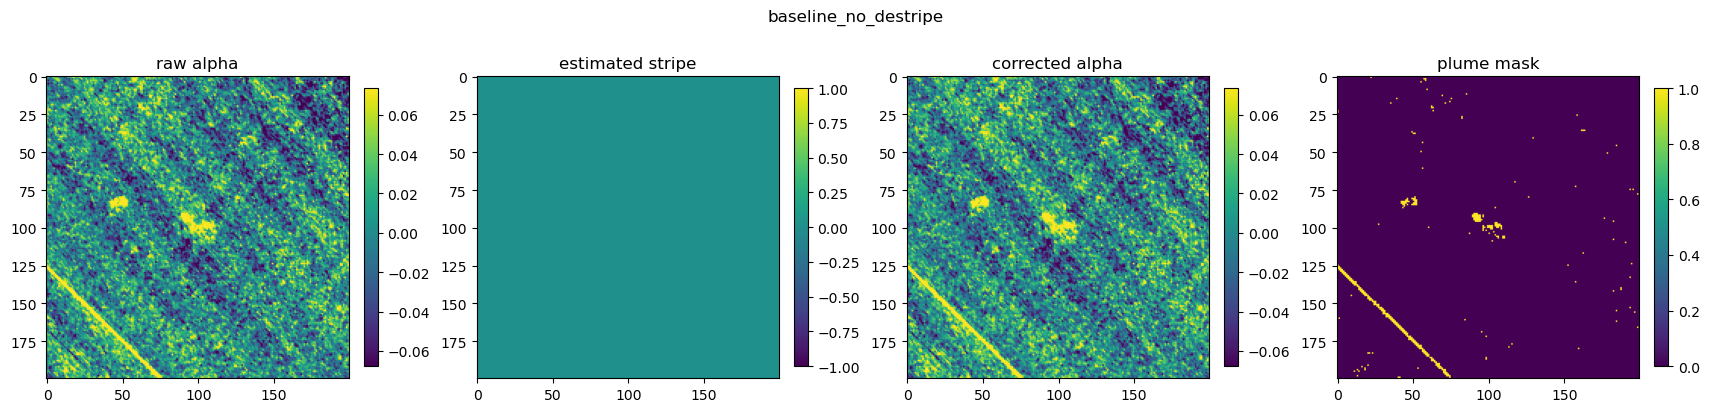

In [9]:

# ============================================================
# 8. Load data and run baseline Iterative MF
# ============================================================
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

roi_df, wavelengths, spectra = load_roi_spectra_csv(ROI_CSV)
cube, ys, xs = spectra_to_cube(roi_df, spectra)
valid_mask_full = make_valid_pixel_mask(
    cube,
    nodata_values=NODATA_VALUES,
    require_positive=REQUIRE_POSITIVE,
    min_valid_fraction=MIN_VALID_FRACTION,
)

cube_sel, wave_sel, band_sel = select_bands(cube, wavelengths, WL_MIN, WL_MAX)
valid_mask = make_valid_pixel_mask(
    cube_sel,
    nodata_values=NODATA_VALUES,
    require_positive=REQUIRE_POSITIVE,
    min_valid_fraction=MIN_VALID_FRACTION,
)

mod_wave, alpha_grid, mod_spectra = load_ch4_modtran_csv(MODTRAN_CSV)
mod_resampled = gaussian_srf_resample(mod_wave, mod_spectra, wave_sel, FWHM_NM)
uas, _ = compute_uas_log_slope(
    alpha_grid=alpha_grid,
    spectra_grid=mod_resampled,
    alpha_min=UAS_ALPHA_MIN,
    alpha_max=UAS_ALPHA_MAX,
)

print(f"ROI table: {roi_df.shape}")
print(f"Full cube: {cube.shape}")
print(f"Selected cube: {cube_sel.shape}")
print(f"Valid pixels: {int(np.sum(valid_mask))} / {valid_mask.size}")
print("Broad slopes:", BROAD_SLOPES)
print("Thin slopes:", THIN_SLOPES)

baseline = run_baseline_iterative_mf(
    cube=cube_sel,
    uas=uas,
    valid_mask=valid_mask,
    n_iter=N_ITER,
    nsigma=NSIGMA,
    reg=REG,
    rcond=RCOND,
    verbose=True,
)

results = {"baseline_no_destripe": baseline}
plot_case_overview("baseline_no_destripe", baseline, output_dir=OUTPUT_DIR)


In [10]:

# ============================================================
# 9. Run final-only hybrid experiments
# ============================================================
if RUN_FINAL_ONLY_HYBRID:
    if RUN_BROAD_ONLY_REFERENCE:
        name = "broad_median_only"
        print("\n" + "=" * 80)
        print(f"Running {name}")
        print("=" * 80)
        results[name] = build_final_only_hybrid_result(baseline, thin_method=None, case_name=name)

    for method in THIN_STAT_METHODS:
        name = f"broad_median_then_thin_{method}"
        print("\n" + "=" * 80)
        print(f"Running {name}")
        print("=" * 80)
        results[name] = build_final_only_hybrid_result(baseline, thin_method=method, case_name=name)

summary_df = summarize_results_table(results)
display(summary_df)
summary_df.to_csv(OUTPUT_DIR / "summary_df.csv", index=False)



Running broad_median_only

Running broad_median_then_thin_median

Running broad_median_then_thin_mean

Running broad_median_then_thin_trimmed_mean

Running broad_median_then_thin_sigma_clipped_mean

Running broad_median_then_thin_mode

Running broad_median_then_thin_quantile_75

Running broad_median_then_thin_quantile_90

Running broad_median_then_thin_upper_mean_75


,name,destripe_when,broad_method,thin_method,broad_line_bin_width,thin_line_bin_width,threshold,median,robust_std,plume_pixels,valid_pixels,converged_iter
0,baseline_no_destripe,none,None,None,NaN,NaN,0.094378,0.000555,0.031274,407,40000,None
1,broad_median_only,final_only_hybrid,median,None,18.0,2.0,0.086742,0.000366,0.028792,417,40000,None
2,broad_median_then_thin_median,final_only_hybrid,median,median,18.0,2.0,0.084043,0.000352,0.027897,271,40000,None
3,broad_median_then_thin_mean,final_only_hybrid,median,mean,18.0,2.0,0.086349,0.000837,0.028504,240,40000,None
4,broad_median_then_thin_trimmed_mean,final_only_hybrid,median,trimmed_mean,18.0,2.0,0.084623,0.000361,0.028087,258,40000,None
5,broad_median_then_thin_sigma_clipped_mean,final_only_hybrid,median,sigma_clipped_mean,18.0,2.0,0.084197,0.000145,0.028017,265,40000,None
6,broad_median_then_thin_mode,final_only_hybrid,median,mode,18.0,2.0,0.093921,0.001343,0.030860,237,40000,None
7,broad_median_then_thin_quantile_75,final_only_hybrid,median,quantile_75,18.0,2.0,0.085442,0.001164,0.028093,233,40000,None
8,broad_median_then_thin_quantile_90,final_only_hybrid,median,quantile_90,18.0,2.0,0.089770,0.002679,0.029030,171,40000,None
9,broad_median_then_thin_upper_mean_75,final_only_hybrid,median,upper_mean_75,18.0,2.0,0.098523,0.006058,0.030822,117,40000,None


In [11]:

# ============================================================
# 10. Optional: run each-iteration hybrid experiments
# ============================================================
if RUN_EACH_ITER_HYBRID:
    for method in THIN_STAT_METHODS:
        name = f"each_iter_broad_median_then_thin_{method}"
        print("\n" + "=" * 80)
        print(f"Running {name}")
        print("=" * 80)
        results[name] = run_iterative_mf_with_each_iter_hybrid(
            cube=cube_sel,
            uas=uas,
            valid_mask=valid_mask,
            thin_method=method,
            verbose=True,
        )
    summary_df = summarize_results_table(results)
    display(summary_df)
    summary_df.to_csv(OUTPUT_DIR / "summary_df.csv", index=False)



Running each_iter_broad_median_then_thin_median
iter 01 | bg=  40000 | thr=+9.029378e-02 | rstd=3.017020e-02 | plume=    171 | hybrid thin=median
iter 02 | bg=  39829 | thr=+8.505334e-02 | rstd=2.838609e-02 | plume=    209 | hybrid thin=median
iter 03 | bg=  39791 | thr=+8.472215e-02 | rstd=2.823512e-02 | plume=    234 | hybrid thin=median
iter 04 | bg=  39766 | thr=+8.468707e-02 | rstd=2.822366e-02 | plume=    241 | hybrid thin=median
iter 05 | bg=  39759 | thr=+8.462484e-02 | rstd=2.819298e-02 | plume=    246 | hybrid thin=median

Running each_iter_broad_median_then_thin_mean
iter 01 | bg=  40000 | thr=+9.114764e-02 | rstd=3.050664e-02 | plume=    139 | hybrid thin=mean
iter 02 | bg=  39861 | thr=+8.661225e-02 | rstd=2.890180e-02 | plume=    186 | hybrid thin=mean
iter 03 | bg=  39814 | thr=+8.648131e-02 | rstd=2.877678e-02 | plume=    195 | hybrid thin=mean
iter 04 | bg=  39805 | thr=+8.661458e-02 | rstd=2.881869e-02 | plume=    198 | hybrid thin=mean
iter 05 | bg=  39802 | thr=+8.

,name,destripe_when,broad_method,thin_method,broad_line_bin_width,thin_line_bin_width,threshold,median,robust_std,plume_pixels,valid_pixels,converged_iter
0,baseline_no_destripe,none,None,None,NaN,NaN,0.094378,0.000555,0.031274,407,40000,None
1,broad_median_only,final_only_hybrid,median,None,18.0,2.0,0.086742,0.000366,0.028792,417,40000,None
2,broad_median_then_thin_median,final_only_hybrid,median,median,18.0,2.0,0.084043,0.000352,0.027897,271,40000,None
3,broad_median_then_thin_mean,final_only_hybrid,median,mean,18.0,2.0,0.086349,0.000837,0.028504,240,40000,None
4,broad_median_then_thin_trimmed_mean,final_only_hybrid,median,trimmed_mean,18.0,2.0,0.084623,0.000361,0.028087,258,40000,None
5,broad_median_then_thin_sigma_clipped_mean,final_only_hybrid,median,sigma_clipped_mean,18.0,2.0,0.084197,0.000145,0.028017,265,40000,None
6,broad_median_then_thin_mode,final_only_hybrid,median,mode,18.0,2.0,0.093921,0.001343,0.030860,237,40000,None
7,broad_median_then_thin_quantile_75,final_only_hybrid,median,quantile_75,18.0,2.0,0.085442,0.001164,0.028093,233,40000,None
8,broad_median_then_thin_quantile_90,final_only_hybrid,median,quantile_90,18.0,2.0,0.089770,0.002679,0.029030,171,40000,None
9,broad_median_then_thin_upper_mean_75,final_only_hybrid,median,upper_mean_75,18.0,2.0,0.098523,0.006058,0.030822,117,40000,None


,name,destripe_when,broad_method,thin_method,broad_line_bin_width,thin_line_bin_width,threshold,median,robust_std,plume_pixels,valid_pixels,converged_iter
2,broad_median_then_thin_median,final_only_hybrid,median,median,18.0,2.0,0.084043,0.000352,0.027897,271,40000,None
5,broad_median_then_thin_sigma_clipped_mean,final_only_hybrid,median,sigma_clipped_mean,18.0,2.0,0.084197,0.000145,0.028017,265,40000,None
4,broad_median_then_thin_trimmed_mean,final_only_hybrid,median,trimmed_mean,18.0,2.0,0.084623,0.000361,0.028087,258,40000,None
7,broad_median_then_thin_quantile_75,final_only_hybrid,median,quantile_75,18.0,2.0,0.085442,0.001164,0.028093,233,40000,None
10,each_iter_broad_median_then_thin_median,each_iter_hybrid,median,median,NaN,NaN,0.084625,0.000046,0.028193,246,40000,None
12,each_iter_broad_median_then_thin_trimmed_mean,each_iter_hybrid,median,trimmed_mean,NaN,NaN,0.085163,0.000006,0.028386,230,40000,None
13,each_iter_broad_median_then_thin_sigma_clipped...,each_iter_hybrid,median,sigma_clipped_mean,NaN,NaN,0.085222,-0.000051,0.028424,228,40000,None
15,each_iter_broad_median_then_thin_quantile_75,each_iter_hybrid,median,quantile_75,NaN,NaN,0.086267,0.000977,0.028430,213,40000,None
3,broad_median_then_thin_mean,final_only_hybrid,median,mean,18.0,2.0,0.086349,0.000837,0.028504,240,40000,None
1,broad_median_only,final_only_hybrid,median,None,18.0,2.0,0.086742,0.000366,0.028792,417,40000,None


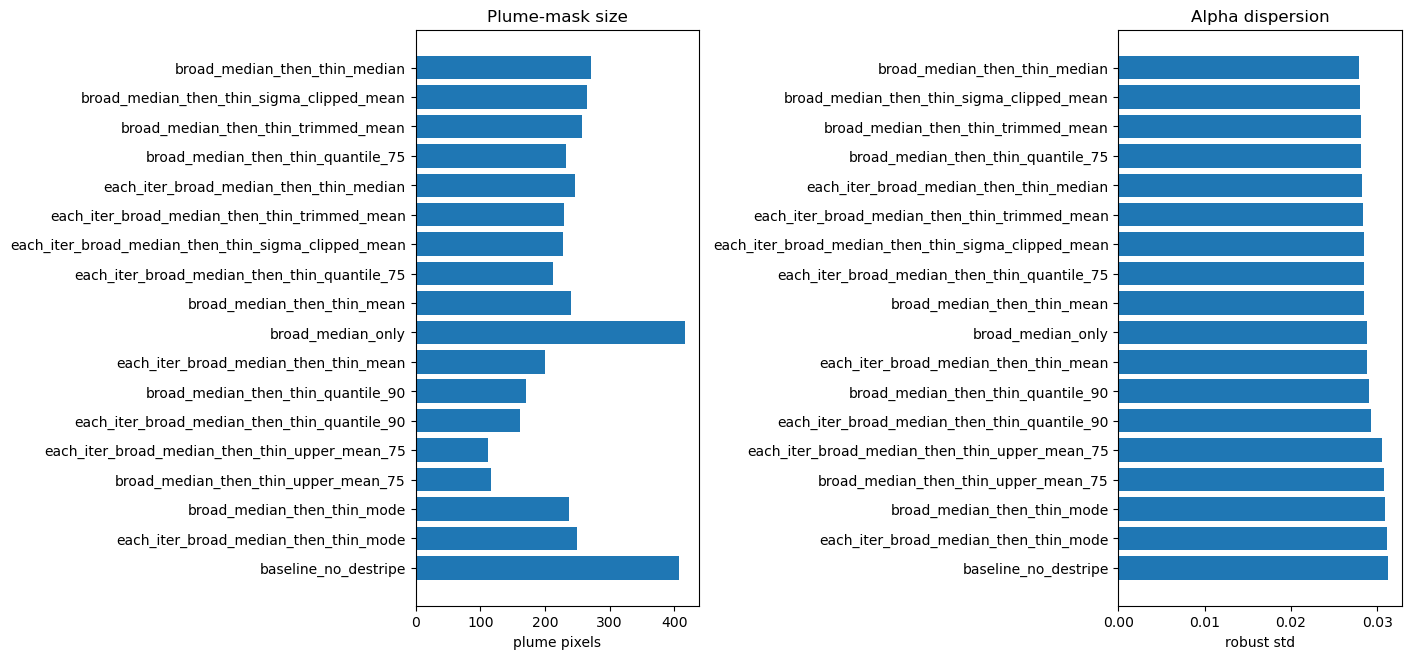

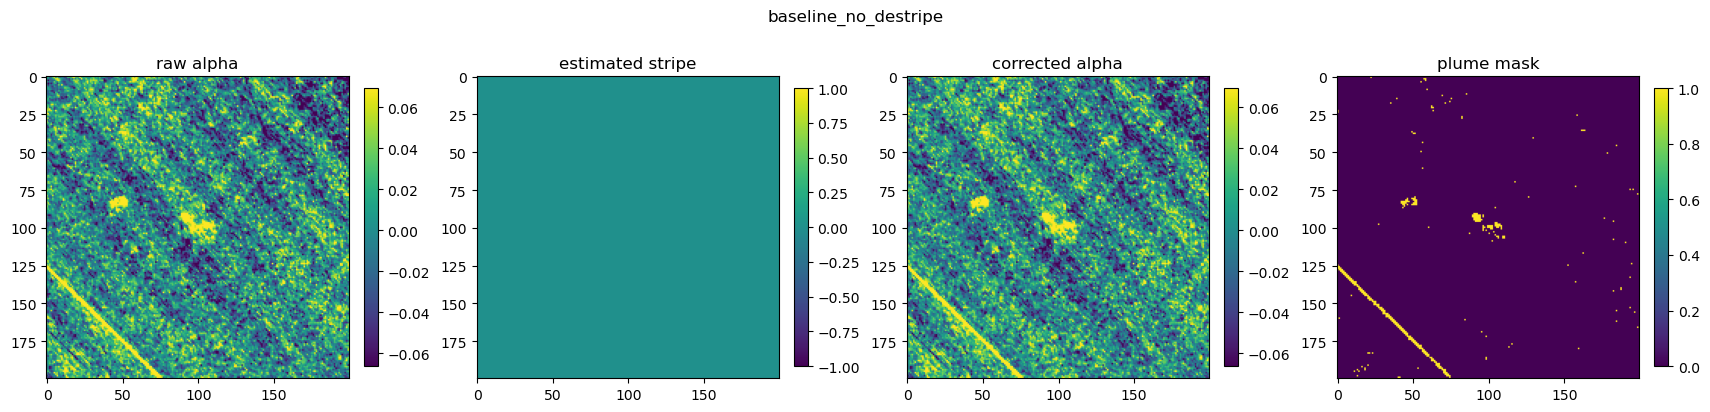

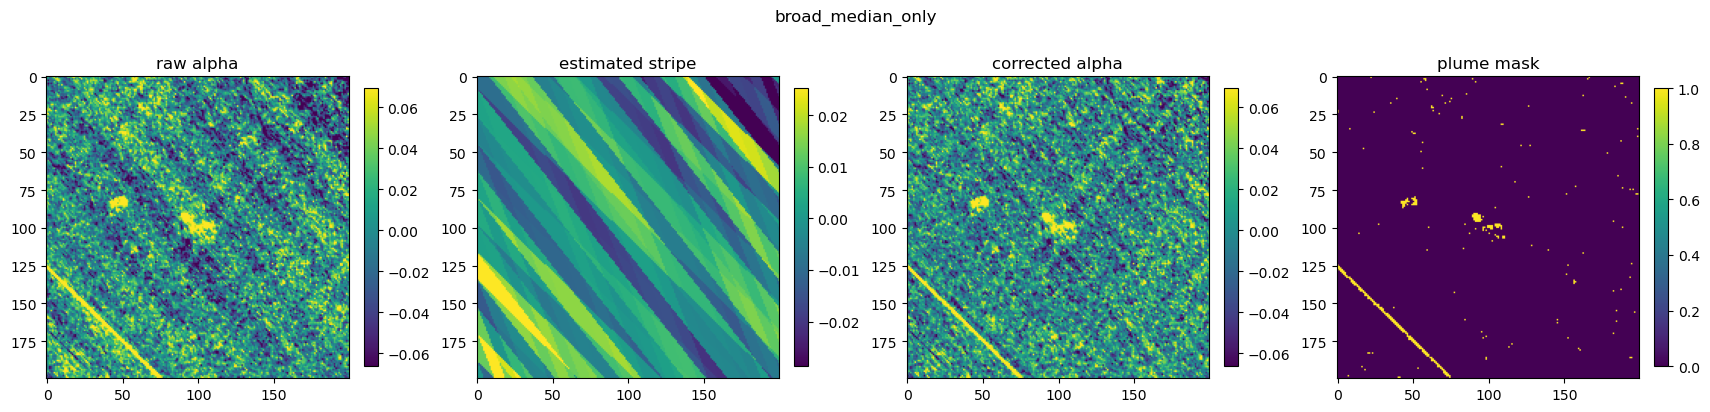

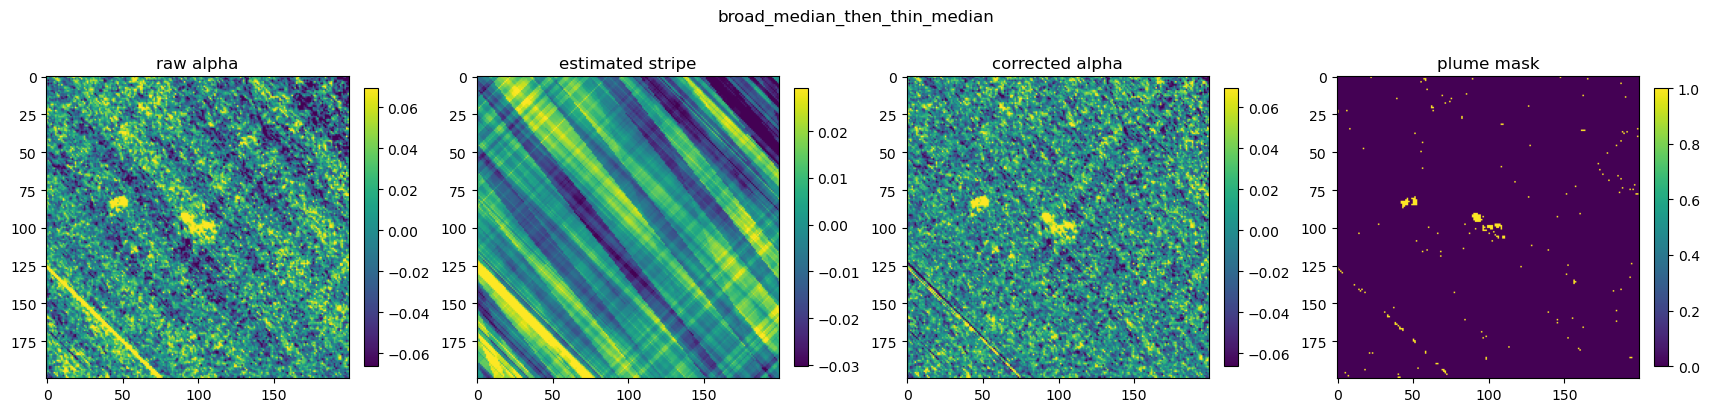

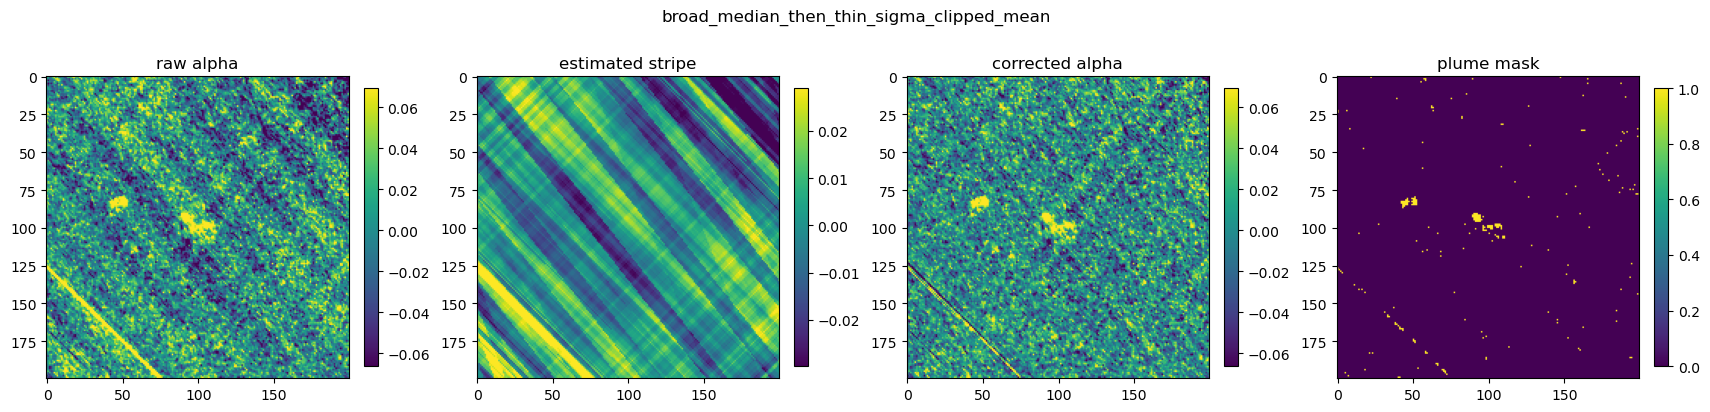

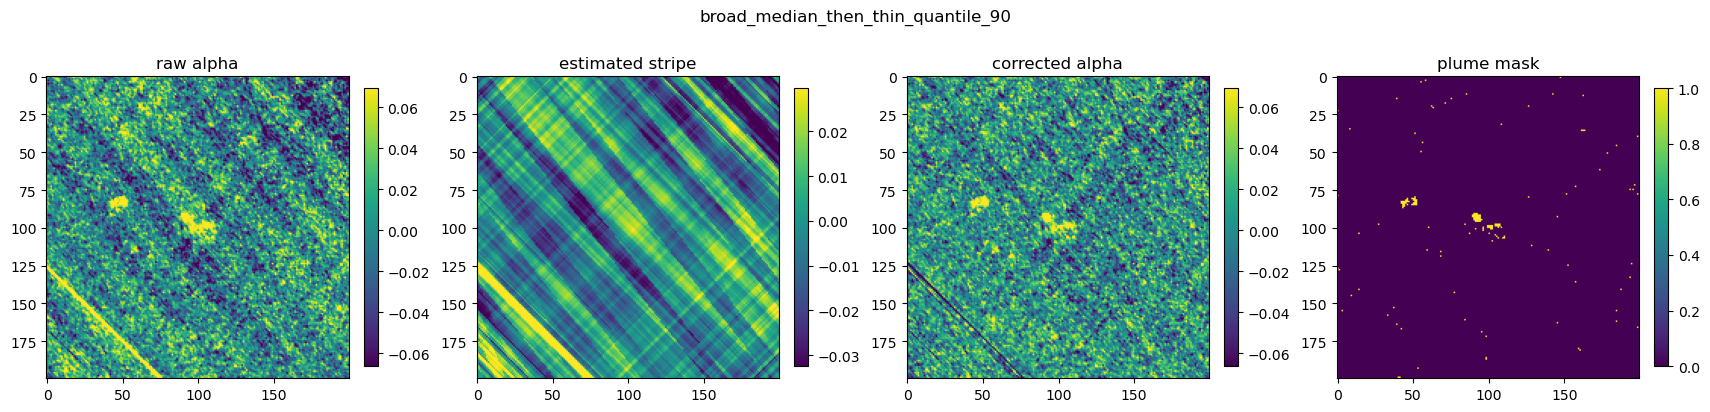

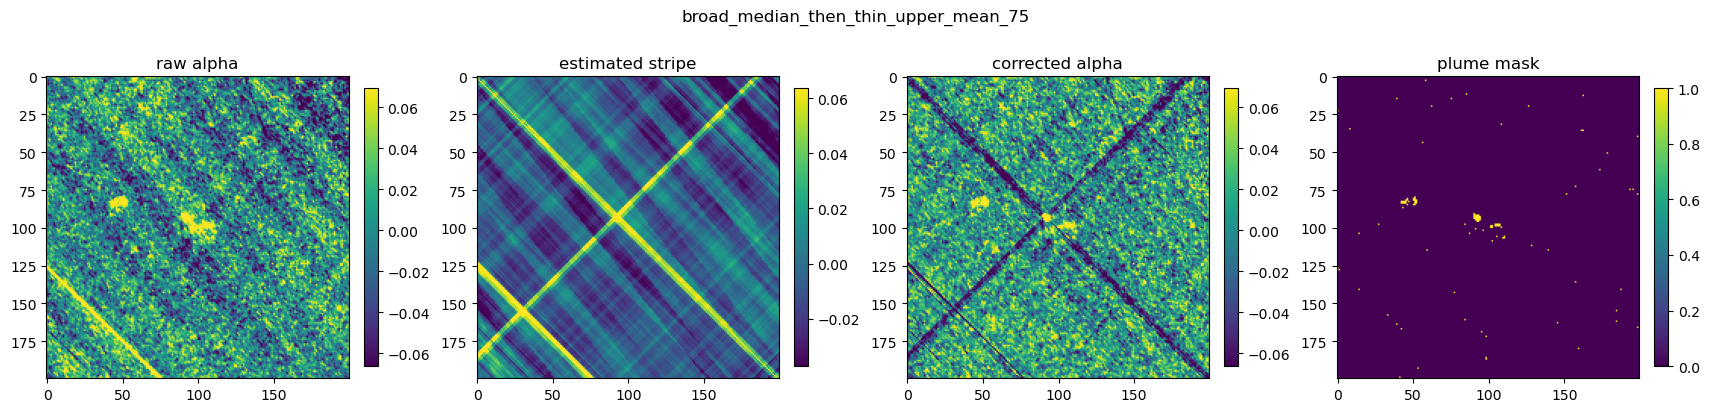

Saved all outputs to: D:\research\code\outputs_hybrid_broad_median_thin_stats


In [12]:

# ============================================================
# 11. Visual comparison and save outputs
# ============================================================
summary_df = summarize_results_table(results)
display(summary_df.sort_values(["robust_std", "plume_pixels"]))
plot_summary(summary_df, output_dir=OUTPUT_DIR)

common_limits = robust_limits(
    [res["alpha_final_raw"] for res in results.values()] + [res["alpha_final_corrected"] for res in results.values()],
    mask=valid_mask,
)

# 見たいケースを必要に応じて変更
cases_to_plot = [
    "baseline_no_destripe",
    "broad_median_only",
    "broad_median_then_thin_median",
    "broad_median_then_thin_sigma_clipped_mean",
    "broad_median_then_thin_quantile_90",
    "broad_median_then_thin_upper_mean_75",
]

for name in cases_to_plot:
    if name in results:
        plot_case_overview(name, results[name], output_dir=OUTPUT_DIR, common_limits=common_limits)

# すべて保存
for name, res in results.items():
    save_case_outputs(res, name, OUTPUT_DIR, ys=ys, xs=xs)

summary_df.to_csv(OUTPUT_DIR / "summary_df.csv", index=False)
np.save(OUTPUT_DIR / "selected_wavelengths.npy", wave_sel)
np.save(OUTPUT_DIR / "selected_uas.npy", uas)
print(f"Saved all outputs to: {OUTPUT_DIR.resolve()}")



## 使い方メモ

### 基本の処理順

```text
Iterative MF baseline alpha
  -> broad cleanup: fixed slopes + line_bin_width=18 + median only
  -> thin cleanup : thin slopes + line_bin_width=2 + various statistics
  -> corrected alpha / plume mask
```

### 太い線の調整

太いセンサ由来ノイズが残る場合は、まず以下を調整してください。

```python
BROAD_SLOPES = [0.9775, 1.2664, 2.5575]
BROAD_LINE_BIN_WIDTH = 18.0
BROAD_MIN_PIXELS_PER_LINE = 80
```

太い帯がもっと幅広い場合は `BROAD_LINE_BIN_WIDTH = 24.0` などにします。  
逆に細かい構造まで消えすぎる場合は `12.0` などに下げます。

### 細い線の統計量

細い高 alpha 線は、まず以下がおすすめです。

1. `median`
2. `sigma_clipped_mean`
3. `trimmed_mean`
4. `quantile_90` または `upper_mean_75`

`mean` は plume や外れ値に引っ張られやすく、`mode` は histogram bin 数に依存します。

### each-iteration 版

`RUN_EACH_ITER_HYBRID = True` にすると、各 iteration の plume 判定前に broad+thin を入れます。  
重いですが、線状 artifact が背景 mask 更新を壊している場合には試す価値があります。
